In [1]:
!pip install -q FedMARS ucimlrepo
from ucimlrepo import fetch_ucirepo
from fedmars import FedMARS, FedMARSConfig, dirichlet_partition

In [2]:
import math
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from IPython.display import display, Markdown
from tqdm.auto import tqdm


In [3]:
import gc
import copy
import random
import warnings
from functools import lru_cache

warnings.filterwarnings("ignore")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BASE_SEED = 2026
UCI_ID = 53
ALPHAS = [1.0, 0.5, 0.1]
LOCAL_EPOCH_GRID = [1, 5, 10]
TARGET_VAL_ACCURACY = 0.95

EXPERIMENT_SEEDS = [2026, 2027, 2028, 2029, 2030]
NUM_ROUNDS = 40
LOCAL_EPOCHS = 1
LOCAL_BATCH_SIZE = 32
SERVER_EVAL_BATCH_SIZE = 256
LOCAL_LR = 0.01
WEIGHT_DECAY = 0.0
MAX_GRAD_NORM = 5.0
CLIENT_FRACTION = 1.0
DEFAULT_NUM_CLIENTS = 10
MIN_CLIENT_SIZE = 4
DIRICHLET_ALPHA = 0.50
PARAM_BITS = 32
LABEL_SMOOTHING = 0.0

TEST_RATIO = 0.20
VAL_RATIO_WITHIN_REMAINDER = 0.25
FOCUS_LOCAL_EPOCH_FOR_HETEROGENEITY_FIG = 5
FOCUS_ALPHA_FOR_LOCAL_TRAINING_FIG = 0.10

MIN_ROWS = 80
MAX_ROWS = 50000
MIN_FEATURES = 2
MAX_FEATURES = 1024
MIN_CLASSES = 2
MAX_CLASSES = 20
MIN_CLASS_COUNT = 5

METHOD_ORDER = [
    "FedMARS",
    "FedAvg",
    "FedProx",
    "SCAFFOLD",
    "FedDyn",
    "MIME",
]

plt.rcParams.update({
    "figure.dpi": 140,
    "font.size": 13,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "lines.linewidth": 2.2,
})

if DEVICE == "cpu":
    try:
        torch.set_num_threads(max(1, min(4, os.cpu_count() or 1)))
    except Exception:
        pass

def set_seed(seed: int) -> None:
    seed = int(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    try:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except Exception:
        pass


# -----------------------------
# dataset fetch / validation
# -----------------------------
def _to_single_target(y_obj):
    if isinstance(y_obj, pd.Series):
        return y_obj.copy()
    if isinstance(y_obj, pd.DataFrame):
        if y_obj.shape[1] != 1:
            return None
        return y_obj.iloc[:, 0].copy()
    if y_obj is None:
        return None
    arr = np.asarray(y_obj)
    if arr.ndim == 1:
        return pd.Series(arr)
    if arr.ndim == 2 and arr.shape[1] == 1:
        return pd.Series(arr[:, 0])
    return None


def _as_feature_df(x_obj):
    if isinstance(x_obj, pd.DataFrame):
        return x_obj.copy()
    if isinstance(x_obj, np.ndarray):
        if x_obj.ndim != 2:
            return None
        cols = [f"f{i}" for i in range(x_obj.shape[1])]
        return pd.DataFrame(x_obj, columns=cols)
    return None


@lru_cache(maxsize=None)
def fetch_uci_summary(uci_id: int):
    try:
        ds = fetch_ucirepo(id=int(uci_id))
    except Exception as e:
        return None, f"fetch_failed: {type(e).__name__}"

    x_df = _as_feature_df(getattr(ds.data, "features", None))
    y_series = _to_single_target(getattr(ds.data, "targets", None))
    if x_df is None or y_series is None:
        return None, "bad_features_or_target"

    if len(x_df) == 0 or len(y_series) == 0 or len(x_df) != len(y_series):
        return None, "shape_mismatch"

    # no preprocessing -> only accept already numeric, complete datasets
    if x_df.isnull().any().any() or y_series.isnull().any():
        return None, "has_missing"
    if not all(pd.api.types.is_numeric_dtype(dt) for dt in x_df.dtypes):
        return None, "non_numeric_features"

    x_np = x_df.to_numpy()
    if not np.isfinite(x_np).all():
        return None, "non_finite_features"

    y_series = y_series.astype(str)
    counts = y_series.value_counts(dropna=False)
    n_rows = int(len(x_df))
    n_features = int(x_df.shape[1])
    n_classes = int(counts.shape[0])
    min_class_count = int(counts.min())

    if n_rows < MIN_ROWS or n_rows > MAX_ROWS:
        return None, "row_filter"
    if n_features < MIN_FEATURES or n_features > MAX_FEATURES:
        return None, "feature_filter"
    if n_classes < MIN_CLASSES or n_classes > MAX_CLASSES:
        return None, "class_filter"
    if min_class_count < MIN_CLASS_COUNT:
        return None, "minority_too_small"

    dataset_name = getattr(getattr(ds, "metadata", None), "name", None)
    if dataset_name is None:
        dataset_name = getattr(ds, "name", f"UCI {uci_id}")
    if dataset_name is None:
        dataset_name = f"UCI {uci_id}"

    return {
        "uci_id": int(uci_id),
        "dataset_name": str(dataset_name),
        "rows": n_rows,
        "features": n_features,
        "classes": n_classes,
        "min_class_count": min_class_count,
        "X_df": x_df,
        "y_series": y_series,
    }, "ok"



# -----------------------------
# model / evaluation helpers
# -----------------------------
def build_model(input_dim: int, num_classes: int):
    h1 = min(256, max(64, input_dim * 2))
    h2 = min(128, max(32, input_dim))
    return nn.Sequential(
        nn.Linear(input_dim, h1),
        nn.ReLU(),
        nn.Linear(h1, h2),
        nn.ReLU(),
        nn.Linear(h2, num_classes),
    )


def move_batch_to_device(batch, device):
    if isinstance(batch, (list, tuple)):
        return [move_batch_to_device(x, device) for x in batch]
    if torch.is_tensor(batch):
        return batch.to(device)
    return batch


def unpack_batch(batch):
    if not isinstance(batch, (list, tuple)) or len(batch) < 2:
        raise ValueError("Expected batch like (x, y)")
    return batch[0], batch[1]


def evaluate_classifier(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0
    with torch.no_grad():
        for batch in loader:
            x, y = unpack_batch(move_batch_to_device(batch, device))
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += float(loss.detach()) * int(len(y))
            total_correct += int((torch.argmax(logits, dim=1) == y).sum().item())
            total_examples += int(len(y))
    return {
        "loss": float(total_loss / max(total_examples, 1)),
        "accuracy": float(total_correct / max(total_examples, 1)),
        "n": int(total_examples),
    }


def clone_model(model, device):
    return copy.deepcopy(model).to(device)


def detach_state_dict(model_or_state):
    if isinstance(model_or_state, dict):
        return {k: v.detach().clone().cpu() for k, v in model_or_state.items()}
    return {k: v.detach().clone().cpu() for k, v in model_or_state.state_dict().items()}


def load_state_dict_(model, state):
    device = next(model.parameters()).device
    model.load_state_dict({k: v.detach().clone().to(device) for k, v in state.items()})


def count_model_bits(model, param_bits=32):
    return int(sum(int(p.numel()) for p in model.parameters()) * int(param_bits))


def infer_client_weights(clients):
    lengths = np.asarray([len(c.dataset) for c in clients], dtype=float)
    total = float(lengths.sum())
    if total <= 0:
        return {c.client_id: 0.0 for c in clients}
    return {c.client_id: float(length / total) for c, length in zip(clients, lengths)}


def history_curve_metric(history, metric="loss"):
    xs, ys = [], []
    for row in history.get("rounds", []):
        eval_row = row.get("validation", None)
        if eval_row is None:
            eval_row = row.get("eval", None)
        if eval_row is None:
            continue
        if metric not in eval_row:
            continue
        xs.append(int(row["round"]) + 1)
        ys.append(float(eval_row[metric]))
    return xs, ys


def final_metric_from_history(history, metric="loss"):
    xs, ys = history_curve_metric(history, metric=metric)
    if ys:
        return float(ys[-1])
    test_row = history.get("test", {})
    return float(test_row.get(metric, np.nan))


def mean_drift_from_history(history):
    vals = [float(r.get("drift", np.nan)) for r in history.get("rounds", [])]
    vals = [v for v in vals if np.isfinite(v)]
    return float(np.mean(vals)) if vals else np.nan


# -----------------------------
# baseline trainers
# -----------------------------

class BaseFLTrainer:
    def __init__(self, model_fn, device=DEVICE, criterion=None):
        self.model_fn = model_fn
        self.device = device
        self.model = model_fn().to(device)
        self.criterion = criterion if criterion is not None else nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
        self.model_bits = count_model_bits(self.model, PARAM_BITS)

    def _client_seed(self, client, round_idx, offset=0):
        cid = str(client.client_id)
        cid_val = int(cid) if cid.isdigit() else sum((i + 1) * ord(ch) for i, ch in enumerate(cid))
        return int(100000 * round_idx + 1000 * cid_val + offset)

    def _sample_clients(self, clients, round_idx):
        rng = np.random.default_rng(BASE_SEED + round_idx)
        choose = max(1, int(round(CLIENT_FRACTION * len(clients))))
        choose = min(choose, len(clients))
        picked = rng.choice(np.arange(len(clients)), size=choose, replace=False)
        return [clients[int(i)] for i in picked.tolist()]

    def _make_loader(self, dataset, seed, shuffle=True):
        generator = torch.Generator().manual_seed(int(seed))
        return DataLoader(dataset, batch_size=LOCAL_BATCH_SIZE, shuffle=shuffle, generator=generator)

    def _make_optimizer(self, model, lr):
        return torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=WEIGHT_DECAY)

    def evaluate(self, loader):
        return evaluate_classifier(self.model, loader, self.criterion, self.device)

    def _state_update(self, local_state, global_state):
        return {k: local_state[k].detach().clone().cpu() - global_state[k].detach().clone().cpu() for k in global_state}

    def _zero_state_like(self):
        return {k: torch.zeros_like(v).detach().clone().cpu() for k, v in self.model.state_dict().items()}

    def _weighted_average_updates(self, updates, weights, ref_state):
        out = {k: torch.zeros_like(v).detach().clone().cpu() for k, v in ref_state.items()}
        total = float(sum(weights))
        if total <= 0:
            return out
        for update, weight in zip(updates, weights):
            scale = float(weight) / total
            for k in out:
                out[k] += scale * update[k].detach().clone().cpu()
        return out

    def _round_log(self, round_idx, sampled_clients, evaluation=None, extra=None, full_ratio=1.0):
        log = {
            "round": int(round_idx),
            "sampled_clients": [c.client_id for c in sampled_clients],
            "communication_ratio": float(full_ratio),
            "client_to_server_bits": int(self.model_bits * len(sampled_clients) * full_ratio),
            "server_to_client_bits": int(self.model_bits * len(sampled_clients) * full_ratio),
            "selected_layer_ratio": float(full_ratio),
        }
        log["total_bits"] = int(log["client_to_server_bits"] + log["server_to_client_bits"])
        if evaluation is not None:
            log["validation"] = evaluation
        if extra:
            log.update(extra)
        return log

    def _local_sgd_state(self, client, global_state, round_idx, lr):
        local_model = clone_model(self.model, self.device)
        load_state_dict_(local_model, global_state)
        optimizer = self._make_optimizer(local_model, lr)
        loader = self._make_loader(client.dataset, self._client_seed(client, round_idx, 1), shuffle=True)
        local_model.train()
        for _ in range(LOCAL_EPOCHS):
            for batch in loader:
                x, y = unpack_batch(move_batch_to_device(batch, self.device))
                optimizer.zero_grad(set_to_none=True)
                loss = self.criterion(local_model(x), y)
                loss.backward()
                if MAX_GRAD_NORM is not None:
                    torch.nn.utils.clip_grad_norm_(local_model.parameters(), MAX_GRAD_NORM)
                optimizer.step()
        return detach_state_dict(local_model)

    def _prox_local_state(self, client, global_state, round_idx, lr, mu):
        local_model = clone_model(self.model, self.device)
        load_state_dict_(local_model, global_state)
        optimizer = self._make_optimizer(local_model, lr)
        loader = self._make_loader(client.dataset, self._client_seed(client, round_idx, 2), shuffle=True)
        global_ref = {k: v.detach().clone().to(self.device) for k, v in global_state.items()}
        local_model.train()
        for _ in range(LOCAL_EPOCHS):
            for batch in loader:
                x, y = unpack_batch(move_batch_to_device(batch, self.device))
                optimizer.zero_grad(set_to_none=True)
                loss = self.criterion(local_model(x), y)
                prox = 0.0
                for pname, param in local_model.named_parameters():
                    prox = prox + 0.5 * float(mu) * torch.sum((param - global_ref[pname]) ** 2)
                total = loss + prox
                total.backward()
                if MAX_GRAD_NORM is not None:
                    torch.nn.utils.clip_grad_norm_(local_model.parameters(), MAX_GRAD_NORM)
                optimizer.step()
        return detach_state_dict(local_model)

    def _gradient_on_batch(self, model, batch):
        model.zero_grad(set_to_none=True)
        x, y = unpack_batch(move_batch_to_device(batch, self.device))
        loss = self.criterion(model(x), y)
        loss.backward()
        grads = {}
        for pname, param in model.named_parameters():
            if param.grad is None:
                grads[pname] = torch.zeros_like(param).detach().clone().cpu()
            else:
                grads[pname] = param.grad.detach().clone().cpu()
        return grads


class FedAvgBaseline(BaseFLTrainer):
    def fit(self, clients, server_eval_loader=None):
        history = {"method": "FedAvg", "rounds": []}
        weights_all = infer_client_weights(clients)
        for round_idx in range(NUM_ROUNDS):
            sampled = self._sample_clients(clients, round_idx)
            global_state = detach_state_dict(self.model)
            updates, weights = [], []
            for client in sampled:
                local_state = self._local_sgd_state(client, global_state, round_idx, LOCAL_LR)
                updates.append(self._state_update(local_state, global_state))
                weights.append(weights_all[client.client_id])
            avg_update = self._weighted_average_updates(updates, weights, global_state)
            with torch.no_grad():
                for pname, param in self.model.named_parameters():
                    param.add_(avg_update[pname].to(self.device))
            eval_metrics = self.evaluate(server_eval_loader)
            drift = float(sum(torch.mean(avg_update[k] ** 2).item() for k in avg_update))
            history["rounds"].append(self._round_log(round_idx, sampled, eval_metrics, extra={"drift": drift}))
        history["test"] = self.evaluate(server_eval_loader)
        return history


class FedProxBaseline(BaseFLTrainer):
    def fit(self, clients, server_eval_loader=None, mu=0.01):
        history = {"method": "FedProx", "rounds": []}
        weights_all = infer_client_weights(clients)
        for round_idx in range(NUM_ROUNDS):
            sampled = self._sample_clients(clients, round_idx)
            global_state = detach_state_dict(self.model)
            updates, weights = [], []
            for client in sampled:
                local_state = self._prox_local_state(client, global_state, round_idx, LOCAL_LR, mu)
                updates.append(self._state_update(local_state, global_state))
                weights.append(weights_all[client.client_id])
            avg_update = self._weighted_average_updates(updates, weights, global_state)
            with torch.no_grad():
                for pname, param in self.model.named_parameters():
                    param.add_(avg_update[pname].to(self.device))
            eval_metrics = self.evaluate(server_eval_loader)
            drift = float(sum(torch.mean(avg_update[k] ** 2).item() for k in avg_update))
            history["rounds"].append(self._round_log(round_idx, sampled, eval_metrics, extra={"drift": drift}))
        history["test"] = self.evaluate(server_eval_loader)
        return history


class SCAFFOLDBaseline(BaseFLTrainer):
    def fit(self, clients, server_eval_loader=None, lr=None):
        history = {"method": "SCAFFOLD", "rounds": []}
        lr = float(LOCAL_LR if lr is None else lr)
        weights_all = infer_client_weights(clients)
        server_c = self._zero_state_like()
        client_c = {client.client_id: self._zero_state_like() for client in clients}

        for round_idx in range(NUM_ROUNDS):
            sampled = self._sample_clients(clients, round_idx)
            global_state = detach_state_dict(self.model)
            updates, weights, delta_cs = [], [], []

            for client in sampled:
                local_model = clone_model(self.model, self.device)
                load_state_dict_(local_model, global_state)
                loader = self._make_loader(client.dataset, self._client_seed(client, round_idx, 3), shuffle=True)
                steps = 0
                local_model.train()
                named_params = dict(local_model.named_parameters())

                for _ in range(LOCAL_EPOCHS):
                    for batch in loader:
                        x, y = unpack_batch(move_batch_to_device(batch, self.device))
                        local_model.zero_grad(set_to_none=True)
                        loss = self.criterion(local_model(x), y)
                        loss.backward()
                        if MAX_GRAD_NORM is not None:
                            torch.nn.utils.clip_grad_norm_(local_model.parameters(), MAX_GRAD_NORM)
                        with torch.no_grad():
                            for pname, param in named_params.items():
                                grad = torch.zeros_like(param) if param.grad is None else param.grad
                                control = client_c[client.client_id][pname].to(self.device) - server_c[pname].to(self.device)
                                param.add_(-lr * (grad - control + WEIGHT_DECAY * param))
                        steps += 1

                steps = max(steps, 1)
                local_state = detach_state_dict(local_model)
                updates.append(self._state_update(local_state, global_state))
                weights.append(weights_all[client.client_id])

                c_new, delta_c = {}, {}
                for pname in global_state:
                    c_new[pname] = client_c[client.client_id][pname] - server_c[pname] + (global_state[pname] - local_state[pname]) / float(steps * lr)
                    delta_c[pname] = c_new[pname] - client_c[client.client_id][pname]
                client_c[client.client_id] = c_new
                delta_cs.append(delta_c)

            avg_update = self._weighted_average_updates(updates, weights, global_state)
            with torch.no_grad():
                for pname, param in self.model.named_parameters():
                    param.add_(avg_update[pname].to(self.device))

            sampled_fraction = float(len(sampled) / max(len(clients), 1))
            avg_delta_c = self._weighted_average_updates(delta_cs, [1.0 for _ in delta_cs], global_state)
            for pname in server_c:
                server_c[pname] = server_c[pname] + sampled_fraction * avg_delta_c[pname]

            eval_metrics = self.evaluate(server_eval_loader)
            drift = float(sum(torch.mean(avg_update[k] ** 2).item() for k in avg_update))
            history["rounds"].append(self._round_log(round_idx, sampled, eval_metrics, extra={"drift": drift}))

        history["test"] = self.evaluate(server_eval_loader)
        return history


class FedDynBaseline(BaseFLTrainer):
    def fit(self, clients, server_eval_loader=None, alpha=0.01, lr=None):
        history = {"method": "FedDyn", "rounds": []}
        lr = float(LOCAL_LR if lr is None else lr)
        weights_all = infer_client_weights(clients)
        dual = {client.client_id: self._zero_state_like() for client in clients}

        for round_idx in range(NUM_ROUNDS):
            sampled = self._sample_clients(clients, round_idx)
            global_state = detach_state_dict(self.model)
            updates, weights = [], []

            for client in sampled:
                local_model = clone_model(self.model, self.device)
                load_state_dict_(local_model, global_state)
                optimizer = self._make_optimizer(local_model, lr)
                loader = self._make_loader(client.dataset, self._client_seed(client, round_idx, 4), shuffle=True)
                global_ref = {k: v.detach().clone().to(self.device) for k, v in global_state.items()}
                local_model.train()

                for _ in range(LOCAL_EPOCHS):
                    for batch in loader:
                        x, y = unpack_batch(move_batch_to_device(batch, self.device))
                        optimizer.zero_grad(set_to_none=True)
                        loss = self.criterion(local_model(x), y)
                        reg = 0.0
                        lin = 0.0
                        for pname, param in local_model.named_parameters():
                            reg = reg + 0.5 * float(alpha) * torch.sum((param - global_ref[pname]) ** 2)
                            lin = lin + torch.sum(dual[client.client_id][pname].to(self.device) * param)
                        total = loss + reg - lin
                        total.backward()
                        if MAX_GRAD_NORM is not None:
                            torch.nn.utils.clip_grad_norm_(local_model.parameters(), MAX_GRAD_NORM)
                        optimizer.step()

                local_state = detach_state_dict(local_model)
                for pname in dual[client.client_id]:
                    dual[client.client_id][pname] = dual[client.client_id][pname] - float(alpha) * (local_state[pname] - global_state[pname])

                updates.append(self._state_update(local_state, global_state))
                weights.append(weights_all[client.client_id])

            avg_update = self._weighted_average_updates(updates, weights, global_state)
            with torch.no_grad():
                for pname, param in self.model.named_parameters():
                    param.add_(avg_update[pname].to(self.device))

            eval_metrics = self.evaluate(server_eval_loader)
            drift = float(sum(torch.mean(avg_update[k] ** 2).item() for k in avg_update))
            history["rounds"].append(self._round_log(round_idx, sampled, eval_metrics, extra={"drift": drift}))

        history["test"] = self.evaluate(server_eval_loader)
        return history


class MIMEBaseline(BaseFLTrainer):
    def fit(self, clients, server_eval_loader=None, lr=None):
        history = {"method": "MIME", "rounds": []}
        lr = float(LOCAL_LR if lr is None else lr)
        weights_all = infer_client_weights(clients)

        for round_idx in range(NUM_ROUNDS):
            sampled = self._sample_clients(clients, round_idx)
            global_state = detach_state_dict(self.model)

            ref_grads = []
            ref_weights = []
            for client in sampled:
                ref_loader = self._make_loader(client.dataset, self._client_seed(client, round_idx, 5), shuffle=True)
                ref_batch = next(iter(ref_loader))
                ref_model = clone_model(self.model, self.device)
                load_state_dict_(ref_model, global_state)
                ref_grads.append(self._gradient_on_batch(ref_model, ref_batch))
                ref_weights.append(weights_all[client.client_id])

            server_grad = self._weighted_average_updates(ref_grads, ref_weights, self._zero_state_like())

            updates, weights = [], []
            for client in sampled:
                local_model = clone_model(self.model, self.device)
                load_state_dict_(local_model, global_state)
                ref_model = clone_model(self.model, self.device)
                load_state_dict_(ref_model, global_state)
                loader = self._make_loader(client.dataset, self._client_seed(client, round_idx, 6), shuffle=True)
                local_model.train()
                ref_model.train()
                named_params = dict(local_model.named_parameters())

                for _ in range(LOCAL_EPOCHS):
                    for batch in loader:
                        ref_batch_grads = self._gradient_on_batch(ref_model, batch)

                        local_model.zero_grad(set_to_none=True)
                        x, y = unpack_batch(move_batch_to_device(batch, self.device))
                        loss = self.criterion(local_model(x), y)
                        loss.backward()

                        if MAX_GRAD_NORM is not None:
                            torch.nn.utils.clip_grad_norm_(local_model.parameters(), MAX_GRAD_NORM)

                        with torch.no_grad():
                            for pname, param in named_params.items():
                                grad = torch.zeros_like(param) if param.grad is None else param.grad
                                corrected = grad - ref_batch_grads[pname].to(self.device) + server_grad[pname].to(self.device) + WEIGHT_DECAY * param
                                param.add_(-lr * corrected)

                local_state = detach_state_dict(local_model)
                updates.append(self._state_update(local_state, global_state))
                weights.append(weights_all[client.client_id])

            avg_update = self._weighted_average_updates(updates, weights, global_state)
            with torch.no_grad():
                for pname, param in self.model.named_parameters():
                    param.add_(avg_update[pname].to(self.device))

            eval_metrics = self.evaluate(server_eval_loader)
            drift = float(sum(torch.mean(avg_update[k] ** 2).item() for k in avg_update))
            history["rounds"].append(self._round_log(round_idx, sampled, eval_metrics, extra={"drift": drift}))

        history["test"] = self.evaluate(server_eval_loader)
        return history


BASELINES = {
    "FedAvg": FedAvgBaseline,
    "FedProx": FedProxBaseline,
    "SCAFFOLD": SCAFFOLDBaseline,
    "FedDyn": FedDynBaseline,
    "MIME": MIMEBaseline,
}

def prepare_dataset_for_validation(uci_id: int, seed: int):
    info, reason = fetch_uci_summary(int(uci_id))
    if info is None:
        raise RuntimeError(f"Dataset {uci_id} failed preparation: {reason}")

    x_df = info["X_df"]
    y_series = info["y_series"]

    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y_series.astype(str)).astype(np.int64)
    x = x_df.to_numpy(dtype=np.float32, copy=True)

    idx_all = np.arange(len(x))
    stratify_all = y if len(np.unique(y)) > 1 else None
    idx_trainval, idx_test = train_test_split(
        idx_all,
        test_size=TEST_RATIO,
        random_state=int(seed),
        stratify=stratify_all,
    )

    idx_trainval = np.asarray(sorted(idx_trainval), dtype=np.int64)
    idx_test = np.asarray(sorted(idx_test), dtype=np.int64)

    stratify_trainval = y[idx_trainval] if len(np.unique(y[idx_trainval])) > 1 else None
    idx_train, idx_val = train_test_split(
        idx_trainval,
        test_size=VAL_RATIO_WITHIN_REMAINDER,
        random_state=int(seed),
        stratify=stratify_trainval,
    )

    idx_train = np.asarray(sorted(idx_train), dtype=np.int64)
    idx_val = np.asarray(sorted(idx_val), dtype=np.int64)

    x_train = torch.tensor(x[idx_train], dtype=torch.float32)
    y_train = torch.tensor(y[idx_train], dtype=torch.long)
    x_val = torch.tensor(x[idx_val], dtype=torch.float32)
    y_val = torch.tensor(y[idx_val], dtype=torch.long)
    x_test = torch.tensor(x[idx_test], dtype=torch.float32)
    y_test = torch.tensor(y[idx_test], dtype=torch.long)

    return {
        "uci_id": int(info["uci_id"]),
        "dataset_name": info["dataset_name"],
        "rows": int(info["rows"]),
        "features": int(info["features"]),
        "classes": int(info["classes"]),
        "min_class_count": int(info["min_class_count"]),
        "train_rows": int(len(idx_train)),
        "val_rows": int(len(idx_val)),
        "test_rows": int(len(idx_test)),
        "input_dim": int(x.shape[1]),
        "num_classes": int(len(np.unique(y))),
        "train_dataset": TensorDataset(x_train, y_train),
        "val_dataset": TensorDataset(x_val, y_val),
        "test_dataset": TensorDataset(x_test, y_test),
        "label_encoder": label_encoder,
    }


def validation_dataset_info_frame(dataset_info):
    return pd.DataFrame([{
        "uci_id": dataset_info["uci_id"],
        "dataset_name": dataset_info["dataset_name"],
        "rows": dataset_info["rows"],
        "features": dataset_info["features"],
        "classes": dataset_info["classes"],
        "train_rows": dataset_info["train_rows"],
        "val_rows": dataset_info["val_rows"],
        "test_rows": dataset_info["test_rows"],
        "input_dim": dataset_info["input_dim"],
        "num_classes": dataset_info["num_classes"],
    }])


# -----------------------------
# fixed fair partition
# -----------------------------
def fixed_dirichlet_partition(train_dataset, seed: int, alpha: float):
    last_error = None
    for kw in ("seed", "random_state"):
        try:
            parts = dirichlet_partition(
                train_dataset,
                num_clients=int(DEFAULT_NUM_CLIENTS),
                alpha=float(alpha),
                min_size=int(MIN_CLIENT_SIZE),
                **{kw: int(seed)},
            )
            sizes = [len(c.dataset) for c in parts]
            if len(parts) != int(DEFAULT_NUM_CLIENTS):
                raise RuntimeError(f"Expected {DEFAULT_NUM_CLIENTS} clients, got {len(parts)}.")
            if min(sizes) < int(MIN_CLIENT_SIZE):
                raise RuntimeError(f"Partition violated min client size: {sizes}")
            return parts
        except TypeError as e:
            last_error = e
        except Exception as e:
            last_error = e
    raise RuntimeError(
        f"Could not build the fixed {DEFAULT_NUM_CLIENTS}-client Dirichlet partition "
        f"(alpha={alpha}, seed={seed}). Last error: {last_error}"
    )


# -----------------------------
# fair FedMARS wrapper
# -----------------------------
def make_fedmars_validation(model_fn, seed: int, num_clients: int):
    cfg = FedMARSConfig(
        random_state=int(seed),
        device=DEVICE,
        num_rounds=NUM_ROUNDS,
        local_epochs=LOCAL_EPOCHS,
        local_batch_size=LOCAL_BATCH_SIZE,
        client_fraction=CLIENT_FRACTION,
        min_clients_per_round=int(num_clients),
        num_clusters=3,
        num_batches_per_cluster=3,
        transfer_probe_batches=3,
        max_grad_norm=MAX_GRAD_NORM,
        default_budget_fraction=0.70,
        default_threshold=-0.05,
        aggregation_momentum=0.90,
        track_server_to_client_bits=True,
        weight_decay=WEIGHT_DECAY,
        label_smoothing=LABEL_SMOOTHING,
        param_bits=PARAM_BITS,
    )
    return FedMARS(model_fn(), cfg)


# -----------------------------
# metrics / summary helpers
# -----------------------------
def rounds_to_target_from_history(history, target=TARGET_VAL_ACCURACY):
    xs, ys = history_curve_metric(history, metric="accuracy")
    for x, y in zip(xs, ys):
        if float(y) >= float(target):
            return int(x)
    return np.nan


def last_round_value(history, key, default=np.nan):
    rounds = history.get("rounds", [])
    if not rounds:
        return default
    return rounds[-1].get(key, default)


def collect_curve_rows(curve_rows, history, method_name, seed, alpha, local_epochs):
    xs_acc, ys_acc = history_curve_metric(history, metric="accuracy")
    xs_loss, ys_loss = history_curve_metric(history, metric="loss")
    loss_map = {int(x): float(y) for x, y in zip(xs_loss, ys_loss)}
    for x, y_acc in zip(xs_acc, ys_acc):
        curve_rows.append({
            "alpha": float(alpha),
            "local_epochs": int(local_epochs),
            "seed": int(seed),
            "method": str(method_name),
            "round": int(x),
            "val_accuracy": float(y_acc),
            "val_loss": float(loss_map.get(int(x), np.nan)),
        })


def run_single_condition(uci_id: int, alpha: float, local_epochs: int):
    global DIRICHLET_ALPHA, LOCAL_EPOCHS
    DIRICHLET_ALPHA = float(alpha)
    LOCAL_EPOCHS = int(local_epochs)

    run_rows = []
    curve_rows = []
    dataset_info = None

    for seed in tqdm(EXPERIMENT_SEEDS, desc=f"alpha={alpha}, K={local_epochs}", leave=False):
        set_seed(int(seed))
        prepared = prepare_dataset_for_validation(uci_id=int(uci_id), seed=int(seed))
        dataset_info = prepared

        model_fn = lambda inp=prepared["input_dim"], cls=prepared["num_classes"]: build_model(inp, cls)

        val_loader = DataLoader(prepared["val_dataset"], batch_size=SERVER_EVAL_BATCH_SIZE, shuffle=False)
        test_loader = DataLoader(prepared["test_dataset"], batch_size=SERVER_EVAL_BATCH_SIZE, shuffle=False)
        train_clients = fixed_dirichlet_partition(prepared["train_dataset"], seed=int(seed), alpha=float(alpha))

        set_seed(int(seed))
        init_model = model_fn().to(DEVICE)
        init_state = detach_state_dict(init_model)
        del init_model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        for method_name in METHOD_ORDER:
            set_seed(int(seed))
            try:
                if method_name == "FedMARS":
                    trainer = make_fedmars_validation(model_fn, seed=seed, num_clients=DEFAULT_NUM_CLIENTS)
                    load_state_dict_(trainer.model, init_state)
                    history = trainer.fit(
                        train_clients,
                        server_val_loader=val_loader,
                        server_test_loader=None,
                    )
                else:
                    trainer = BASELINES[method_name](model_fn)
                    load_state_dict_(trainer.model, init_state)
                    history = trainer.fit(train_clients, server_eval_loader=val_loader)

                final_test_metrics = trainer.evaluate(test_loader)

                collect_curve_rows(
                    curve_rows=curve_rows,
                    history=history,
                    method_name=method_name,
                    seed=seed,
                    alpha=alpha,
                    local_epochs=local_epochs,
                )

                run_rows.append({
                    "alpha": float(alpha),
                    "local_epochs": int(local_epochs),
                    "seed": int(seed),
                    "method": str(method_name),
                    "final_test_loss": float(final_test_metrics["loss"]),
                    "final_test_accuracy": float(final_test_metrics["accuracy"]),
                    "rounds_to_target": rounds_to_target_from_history(history),
                    "mean_drift": float(mean_drift_from_history(history)),
                    "total_bits_last_round": float(last_round_value(history, "total_bits", np.nan)),
                    "selected_layer_ratio_last_round": float(last_round_value(history, "selected_layer_ratio", np.nan)),
                    "communication_ratio_last_round": float(last_round_value(history, "communication_ratio", np.nan)),
                })

            except Exception as e:
                raise RuntimeError(
                    f"Condition failed | dataset={uci_id} | alpha={alpha} | K={local_epochs} | "
                    f"seed={seed} | method={method_name} | {type(e).__name__}: {e}"
                ) from e
            finally:
                del trainer
                gc.collect()
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

    return pd.DataFrame(run_rows), pd.DataFrame(curve_rows), dataset_info


def run_validation1(uci_id: int):
    all_run_parts = []
    all_curve_parts = []
    dataset_info = None

    for alpha in ALPHAS:
        for local_epochs in LOCAL_EPOCH_GRID:
            run_part, curve_part, info = run_single_condition(
                uci_id=uci_id,
                alpha=float(alpha),
                local_epochs=int(local_epochs),
            )
            all_run_parts.append(run_part)
            all_curve_parts.append(curve_part)
            dataset_info = info

    run_df = pd.concat(all_run_parts, ignore_index=True)
    curve_df = pd.concat(all_curve_parts, ignore_index=True)

    summary_df = (
        run_df.groupby(["alpha", "local_epochs", "method"], as_index=False)
        .agg(
            final_test_accuracy_mean=("final_test_accuracy", "mean"),
            final_test_accuracy_std=("final_test_accuracy", "std"),
            final_test_loss_mean=("final_test_loss", "mean"),
            final_test_loss_std=("final_test_loss", "std"),
            rounds_to_target_mean=("rounds_to_target", "mean"),
            rounds_to_target_std=("rounds_to_target", "std"),
            mean_drift=("mean_drift", "mean"),
            total_bits_last_round_mean=("total_bits_last_round", "mean"),
            selected_layer_ratio_last_round_mean=("selected_layer_ratio_last_round", "mean"),
            communication_ratio_last_round_mean=("communication_ratio_last_round", "mean"),
            seeds_ran=("seed", "nunique"),
        )
    )

    curve_mean_df = (
        curve_df.groupby(["alpha", "local_epochs", "method", "round"], as_index=False)
        .agg(
            val_accuracy_mean=("val_accuracy", "mean"),
            val_accuracy_std=("val_accuracy", "std"),
            val_loss_mean=("val_loss", "mean"),
            val_loss_std=("val_loss", "std"),
        )
    )

    summary_df["final_test_accuracy_std"] = summary_df["final_test_accuracy_std"].fillna(0.0)
    summary_df["final_test_loss_std"] = summary_df["final_test_loss_std"].fillna(0.0)
    summary_df["rounds_to_target_std"] = summary_df["rounds_to_target_std"].fillna(0.0)
    curve_mean_df["val_accuracy_std"] = curve_mean_df["val_accuracy_std"].fillna(0.0)
    curve_mean_df["val_loss_std"] = curve_mean_df["val_loss_std"].fillna(0.0)

    summary_df["method"] = pd.Categorical(summary_df["method"], categories=METHOD_ORDER, ordered=True)
    summary_df = summary_df.sort_values(["alpha", "local_epochs", "method"]).reset_index(drop=True)

    return run_df, curve_df, summary_df, curve_mean_df, dataset_info

def condition_label(alpha, local_epochs):
    return f"α={float(alpha):.2g} | K={int(local_epochs)}"


def _styled_pivot(summary_df, value_col, std_col=None, higher_is_better=True, caption=""):
    mean_df = summary_df.pivot(index="method", columns=["alpha", "local_epochs"], values=value_col)
    ordered_cols = [(float(a), int(k)) for a in ALPHAS for k in LOCAL_EPOCH_GRID]
    mean_df = mean_df.reindex(index=METHOD_ORDER, columns=ordered_cols)

    pretty_df = pd.DataFrame(index=mean_df.index)
    numeric_reference = mean_df.copy()

    if std_col is not None:
        std_df = summary_df.pivot(index="method", columns=["alpha", "local_epochs"], values=std_col)
        std_df = std_df.reindex(index=METHOD_ORDER, columns=ordered_cols)
        for col in mean_df.columns:
            label = condition_label(*col)
            pretty_df[label] = [
                f"{mean_df.loc[idx, col]:.4f} ± {std_df.loc[idx, col]:.4f}"
                if pd.notna(mean_df.loc[idx, col]) else "—"
                for idx in mean_df.index
            ]
    else:
        for col in mean_df.columns:
            label = condition_label(*col)
            pretty_df[label] = [
                f"{mean_df.loc[idx, col]:.1f}" if pd.notna(mean_df.loc[idx, col]) else "—"
                for idx in mean_df.index
            ]

    numeric_reference.columns = [condition_label(*c) for c in numeric_reference.columns]

    def highlight_best(col):
        values = numeric_reference[col.name]
        valid = values.dropna()
        if valid.empty:
            return [""] * len(values)
        best = float(valid.max() if higher_is_better else valid.min())
        out = []
        for value in values:
            if pd.notna(value) and abs(float(value) - best) <= 1e-12:
                out.append("font-weight: 700; background-color: #eef7ee;")
            else:
                out.append("")
        return out

    styler = (
        pretty_df.style
        .set_caption(caption)
        .apply(highlight_best, axis=0)
        .set_properties(**{
            "text-align": "center",
            "font-size": "15px",
            "border": "1px solid #d0d0d0",
        })
        .set_table_styles([
            {"selector": "caption", "props": [("caption-side", "top"), ("font-size", "16px"), ("font-weight", "600")]},
            {"selector": "th", "props": [("font-size", "14px"), ("text-align", "center")]},
        ])
    )
    return styler


def make_accuracy_styler(summary_df):
    return _styled_pivot(
        summary_df=summary_df,
        value_col="final_test_accuracy_mean",
        std_col="final_test_accuracy_std",
        higher_is_better=True,
        caption="Final test accuracy (mean ± std across seeds)",
    )


def make_loss_styler(summary_df):
    return _styled_pivot(
        summary_df=summary_df,
        value_col="final_test_loss_mean",
        std_col="final_test_loss_std",
        higher_is_better=False,
        caption="Final test loss (mean ± std across seeds)",
    )


def make_rounds_styler(summary_df):
    return _styled_pivot(
        summary_df=summary_df,
        value_col="rounds_to_target_mean",
        std_col=None,
        higher_is_better=False,
        caption=f"Rounds to reach validation accuracy {TARGET_VAL_ACCURACY:.2f} (mean across seeds)",
    )


def condition_rank_table(summary_df):
    out = summary_df.copy()
    out["rank"] = out.groupby(["alpha", "local_epochs"])["final_test_accuracy_mean"].rank(
        ascending=False,
        method="min",
    )
    out = out.sort_values(
        ["alpha", "local_epochs", "rank", "final_test_loss_mean", "method"]
    ).reset_index(drop=True)
    cols = [
        "alpha",
        "local_epochs",
        "rank",
        "method",
        "final_test_accuracy_mean",
        "final_test_accuracy_std",
        "final_test_loss_mean",
        "final_test_loss_std",
        "rounds_to_target_mean",
        "mean_drift",
        "selected_layer_ratio_last_round_mean",
        "communication_ratio_last_round_mean",
        "total_bits_last_round_mean",
    ]
    return out[cols]


def _plot_method_curves(ax, subset, y_mean_col, y_std_col, ylabel):
    is_accuracy = "accuracy" in y_mean_col
    loss_upper_bounds = []
    for method in METHOD_ORDER:
        part = subset[subset["method"] == method].sort_values("round")
        if part.empty:
            continue
        x = part["round"].to_numpy(dtype=float)
        y = part[y_mean_col].to_numpy(dtype=float)
        s = part[y_std_col].to_numpy(dtype=float)
        if is_accuracy:
            lower = np.clip(y - s, 0.0, 1.0)
            upper = np.clip(y + s, 0.0, 1.0)
        else:
            lower = np.maximum(y - s, 0.0)
            upper = y + s
            loss_upper_bounds.extend(upper[np.isfinite(upper)].tolist())
        ax.plot(x, y, label=method)
        ax.fill_between(x, lower, upper, alpha=0.12)
    ax.set_xlim(1, NUM_ROUNDS)
    if is_accuracy:
        ax.set_ylim(0.0, 1.0)
    elif loss_upper_bounds:
        ymax = max(loss_upper_bounds)
        ax.set_ylim(0.0, max(1.0, ymax * 1.05))
    ax.grid(True, alpha=0.25)
    ax.set_ylabel(ylabel)


def _panel_figure(curve_mean_df, panel_values, fixed_name, fixed_value, title, y_mean_col, y_std_col, ylabel, panel_label):
    fig, axes = plt.subplots(1, len(panel_values), figsize=(15.2, 4.8), sharey=True)

    for ax, value in zip(np.ravel(axes), panel_values):
        if fixed_name == "local_epochs":
            subset = curve_mean_df[
                (curve_mean_df["alpha"] == float(value)) &
                (curve_mean_df["local_epochs"] == int(fixed_value))
            ].copy()
        else:
            subset = curve_mean_df[
                (curve_mean_df["alpha"] == float(fixed_value)) &
                (curve_mean_df["local_epochs"] == int(value))
            ].copy()

        _plot_method_curves(ax, subset, y_mean_col=y_mean_col, y_std_col=y_std_col, ylabel=ylabel)
        if panel_label == "alpha":
            ax.set_title(f"α = {value}")
        else:
            ax.set_title(f"K = {value}")
        ax.set_xlabel("Communication round")

    fig.suptitle(title, y=1.02, fontsize=16)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.06), ncol=4, frameon=False)
    fig.tight_layout(rect=[0, 0.07, 1, 0.95])
    plt.show()


def plot_heterogeneity_accuracy(curve_mean_df, fixed_local_epochs=FOCUS_LOCAL_EPOCH_FOR_HETEROGENEITY_FIG):
    _panel_figure(
        curve_mean_df=curve_mean_df,
        panel_values=ALPHAS,
        fixed_name="local_epochs",
        fixed_value=fixed_local_epochs,
        title="Validation Accuracy Under Increasing Statistical Heterogeneity",
        y_mean_col="val_accuracy_mean",
        y_std_col="val_accuracy_std",
        ylabel="Validation accuracy",
        panel_label="alpha",
    )


def plot_local_training_accuracy(curve_mean_df, fixed_alpha=FOCUS_ALPHA_FOR_LOCAL_TRAINING_FIG):
    _panel_figure(
        curve_mean_df=curve_mean_df,
        panel_values=LOCAL_EPOCH_GRID,
        fixed_name="alpha",
        fixed_value=fixed_alpha,
        title="Validation Accuracy Under Increasing Local Training",
        y_mean_col="val_accuracy_mean",
        y_std_col="val_accuracy_std",
        ylabel="Validation accuracy",
        panel_label="local_epochs",
    )


def plot_heterogeneity_loss(curve_mean_df, fixed_local_epochs=FOCUS_LOCAL_EPOCH_FOR_HETEROGENEITY_FIG):
    _panel_figure(
        curve_mean_df=curve_mean_df,
        panel_values=ALPHAS,
        fixed_name="local_epochs",
        fixed_value=fixed_local_epochs,
        title="Validation Loss Under Increasing Statistical Heterogeneity",
        y_mean_col="val_loss_mean",
        y_std_col="val_loss_std",
        ylabel="Validation loss",
        panel_label="alpha",
    )


def plot_local_training_loss(curve_mean_df, fixed_alpha=FOCUS_ALPHA_FOR_LOCAL_TRAINING_FIG):
    _panel_figure(
        curve_mean_df=curve_mean_df,
        panel_values=LOCAL_EPOCH_GRID,
        fixed_name="alpha",
        fixed_value=fixed_alpha,
        title="Validation Loss Under Increasing Local Training",
        y_mean_col="val_loss_mean",
        y_std_col="val_loss_std",
        ylabel="Validation loss",
        panel_label="local_epochs",
    )

## Validation 1 setup

,methods,seeds,heterogeneity_alphas,local_epochs_grid,rounds,clients,client_fraction,batch_size,local_lr,weight_decay,split
0,FedMARS + FedAvg + FedProx + SCAFFOLD + FedDyn...,5,"[1.0, 0.5, 0.1]","[1, 5, 10]",40,10,1.0,32,0.01,0.0,60/20/20 (train/validation/test)


alpha=1.0, K=1:   0%|          | 0/5 [00:00<?, ?it/s]

alpha=1.0, K=5:   0%|          | 0/5 [00:00<?, ?it/s]

alpha=1.0, K=10:   0%|          | 0/5 [00:00<?, ?it/s]

...

## Final test loss

,α=1 | K=1,α=1 | K=5,α=1 | K=10,α=0.5 | K=1,α=0.5 | K=5,α=0.5 | K=10,α=0.1 | K=1,α=0.1 | K=5,α=0.1 | K=10
method,,,,,,,,,
FedMARS,0.4220 ± 0.0586,0.1125 ± 0.0436,0.0807 ± 0.0595,0.4131 ± 0.0712,0.1430 ± 0.0463,0.0877 ± 0.0342,0.4182 ± 0.0723,0.2446 ± 0.1140,0.1840 ± 0.1213
FedAvg,0.9085 ± 0.0632,0.2168 ± 0.0522,0.2584 ± 0.3891,0.9102 ± 0.0632,0.2389 ± 0.0356,0.2413 ± 0.2490,0.9206 ± 0.0669,0.2997 ± 0.0483,0.4106 ± 0.3009
FedProx,0.9085 ± 0.0632,0.2169 ± 0.0522,0.2565 ± 0.3850,0.9102 ± 0.0632,0.2389 ± 0.0356,0.1979 ± 0.1590,0.9206 ± 0.0669,0.2998 ± 0.0483,0.4094 ± 0.3005
SCAFFOLD,0.9126 ± 0.0659,0.4370 ± 0.0562,0.2496 ± 0.0383,0.9582 ± 0.0758,0.4616 ± 0.0638,0.2577 ± 0.0509,1.0406 ± 0.1963,0.5996 ± 0.2481,0.3739 ± 0.1661
FedDyn,0.9089 ± 0.0631,0.2234 ± 0.0524,0.2611 ± 0.3813,0.9105 ± 0.0632,0.2457 ± 0.0364,0.2005 ± 0.1508,0.9208 ± 0.0668,0.3058 ± 0.0480,0.4105 ± 0.2849
MIME,0.9085 ± 0.0632,0.4306 ± 0.0542,0.2529 ± 0.0439,0.9102 ± 0.0632,0.4348 ± 0.0525,0.2666 ± 0.0448,0.9206 ± 0.0669,0.4417 ± 0.0498,0.2865 ± 0.0415


## Rounds to target

,α=1 | K=1,α=1 | K=5,α=1 | K=10,α=0.5 | K=1,α=0.5 | K=5,α=0.5 | K=10,α=0.1 | K=1,α=0.1 | K=5,α=0.1 | K=10
method,,,,,,,,,
FedMARS,25.3,11.4,11.2,29.0,16.0,13.0,26.5,20.6,16.5
FedAvg,—,17.5,6.5,—,16.8,11.8,—,21.6,3.0
FedProx,—,17.5,6.5,—,16.8,11.8,—,21.6,3.0
SCAFFOLD,—,31.0,25.5,—,22.0,25.3,—,—,33.0
FedDyn,—,17.5,6.5,—,17.0,12.2,—,21.8,3.0
MIME,—,32.0,21.8,—,29.0,23.0,—,35.5,19.7


## Validation loss: statistical heterogeneity

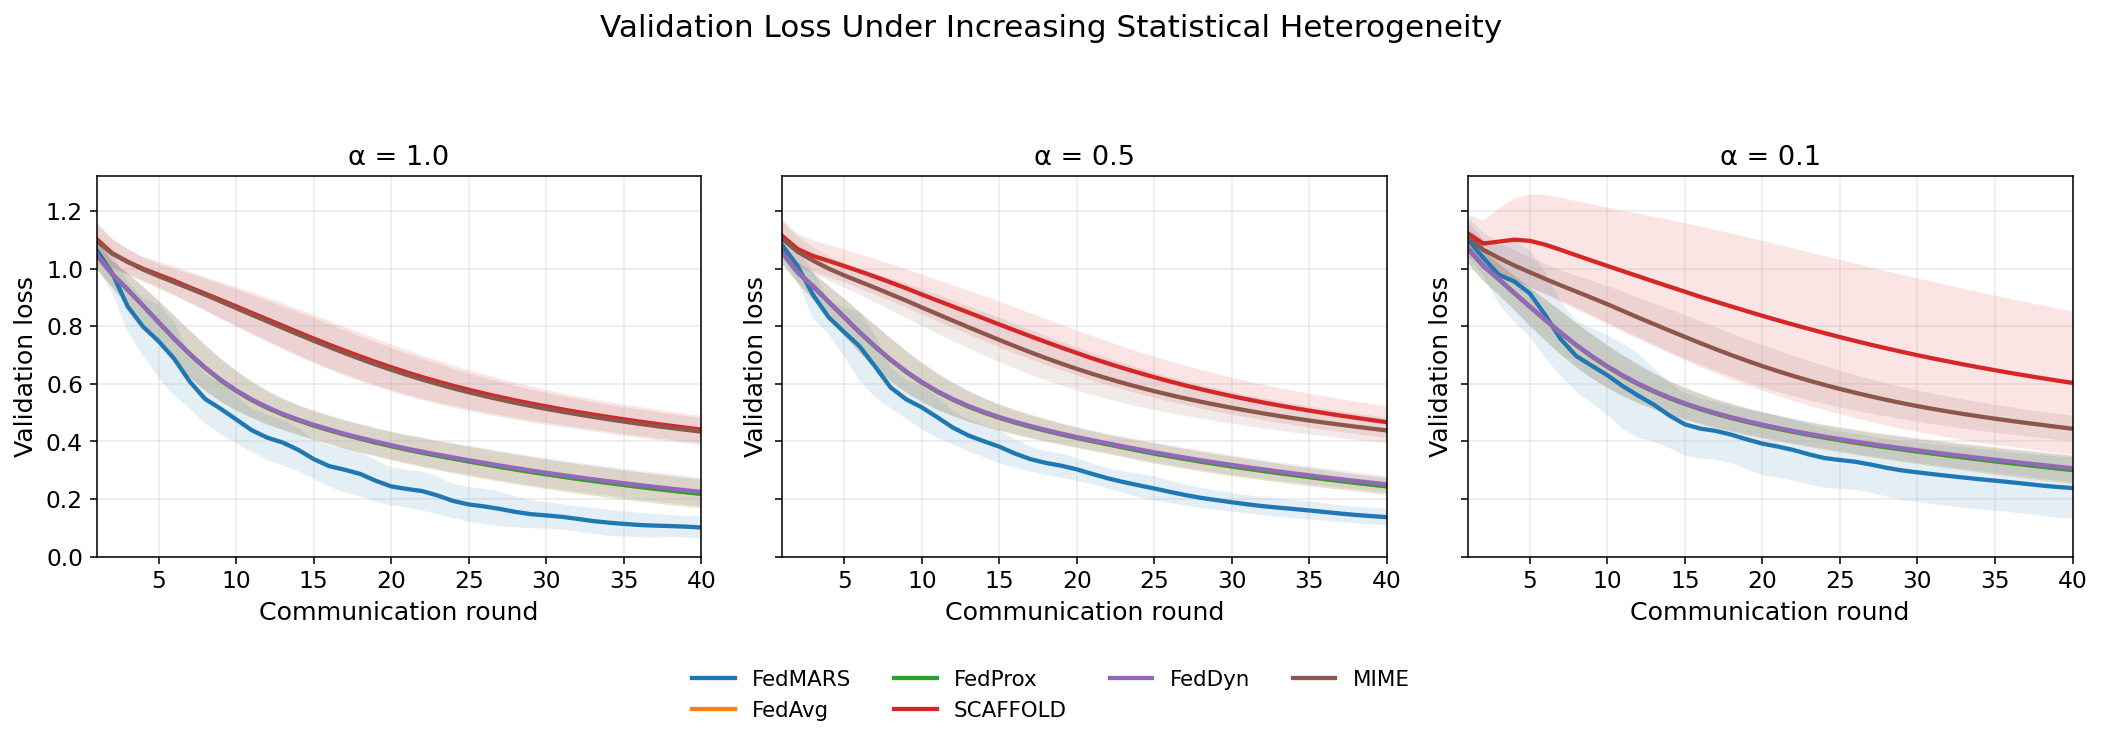

## Validation loss: local training

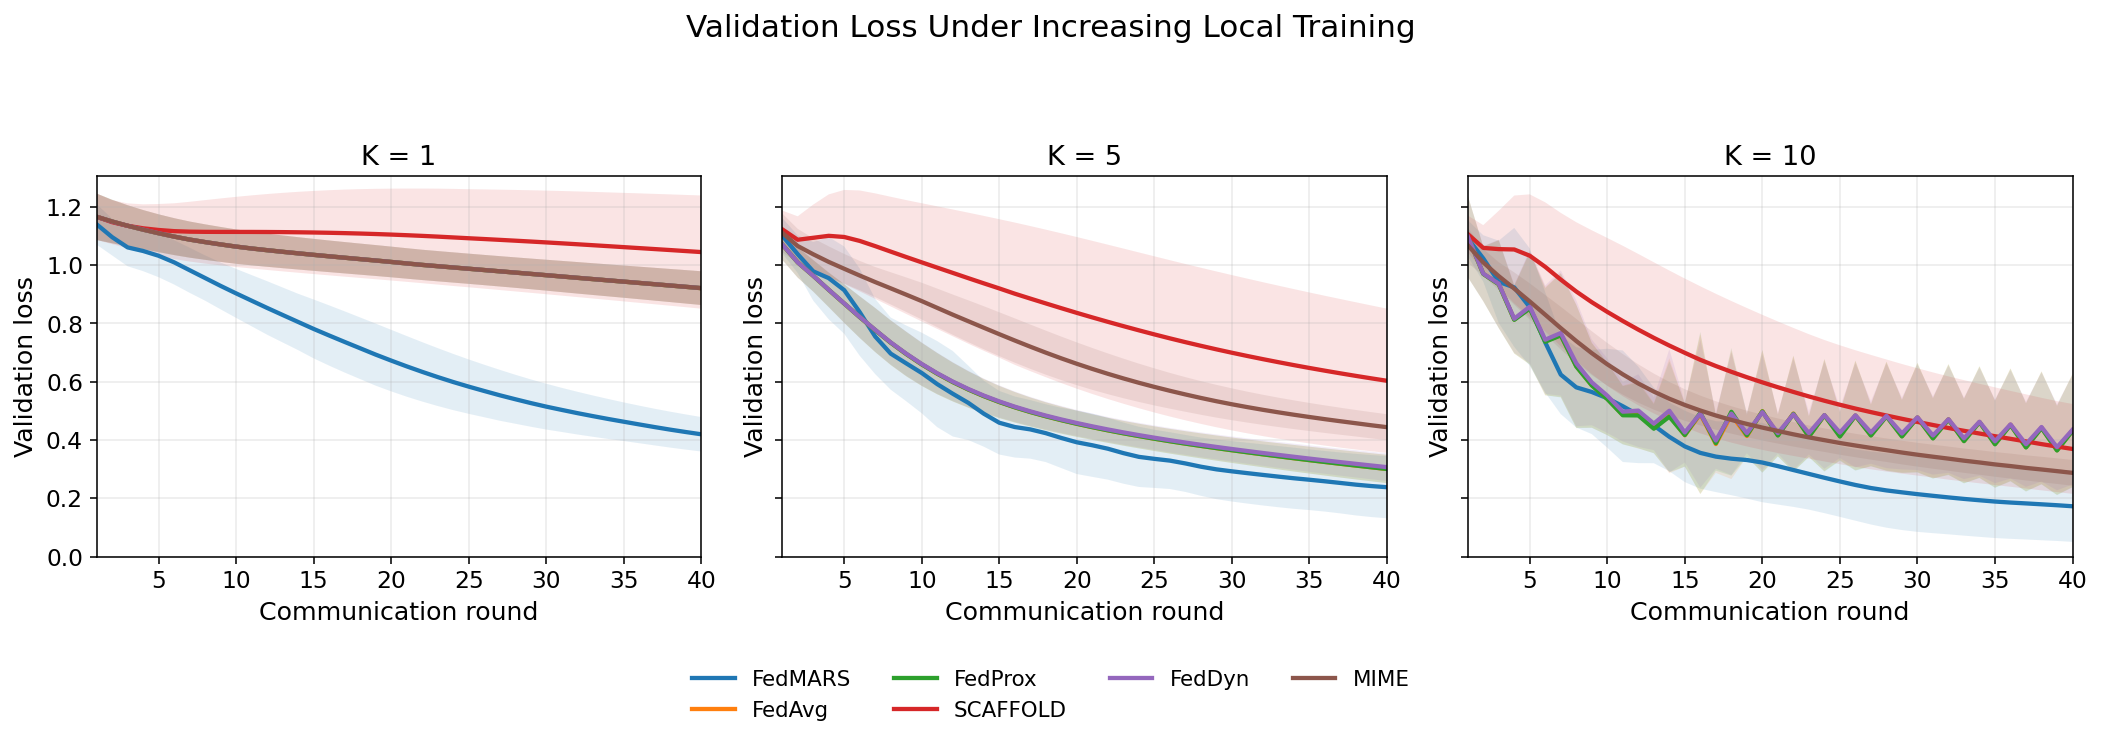

## Validation accuracy: statistical heterogeneity

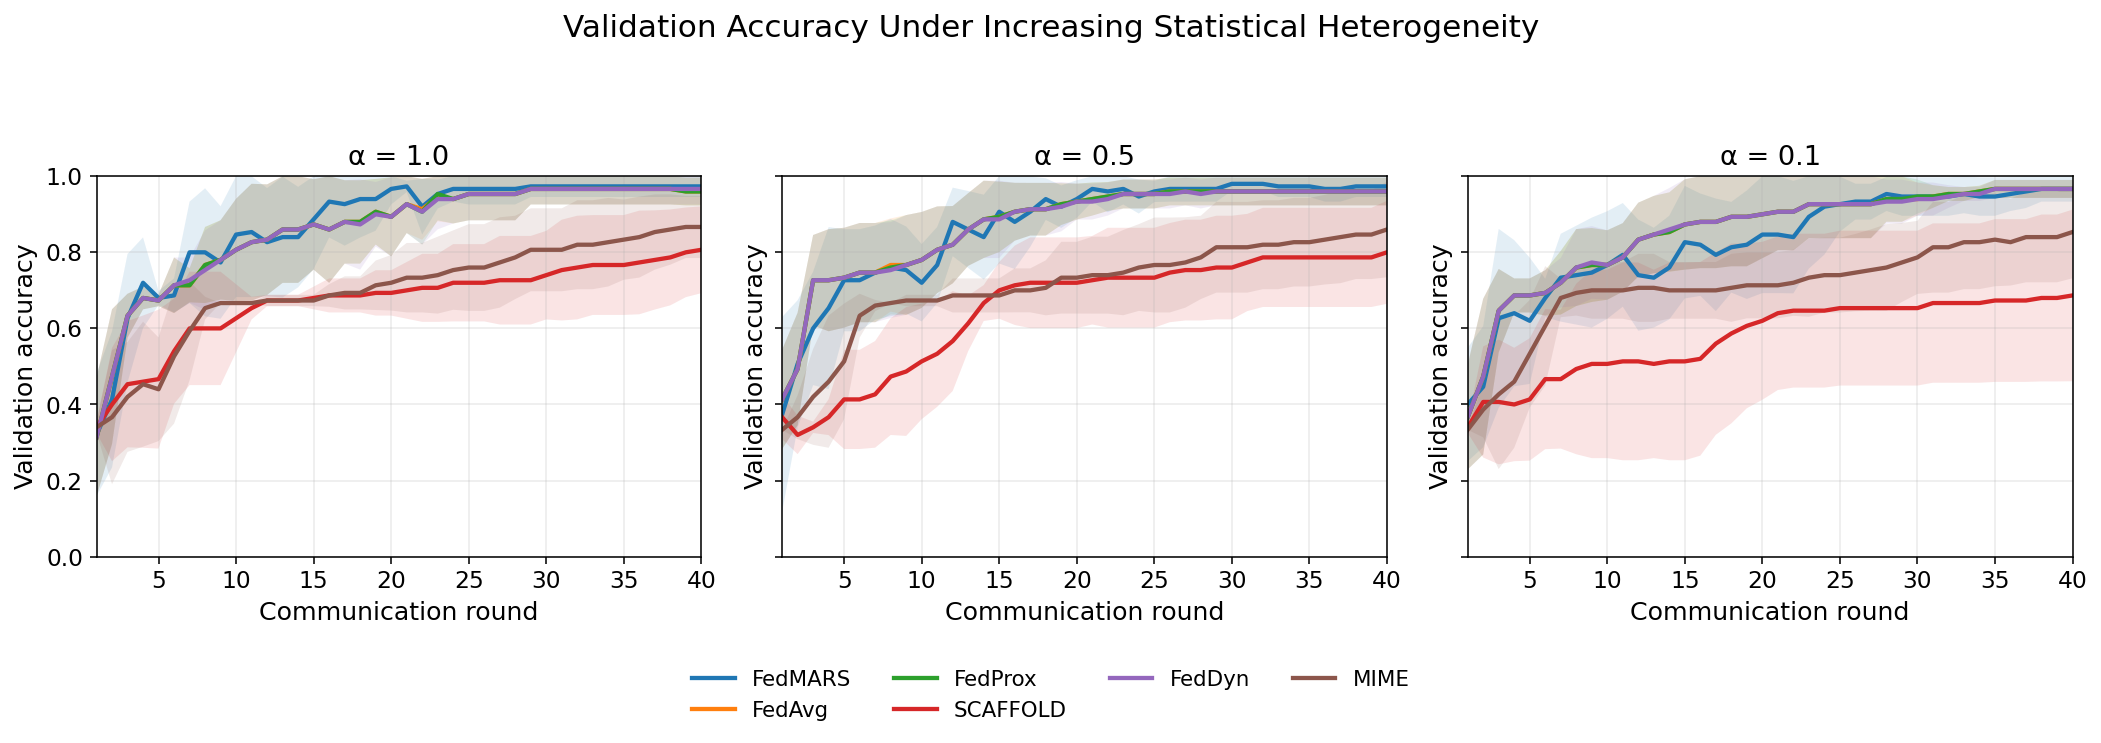

## Validation accuracy: local training

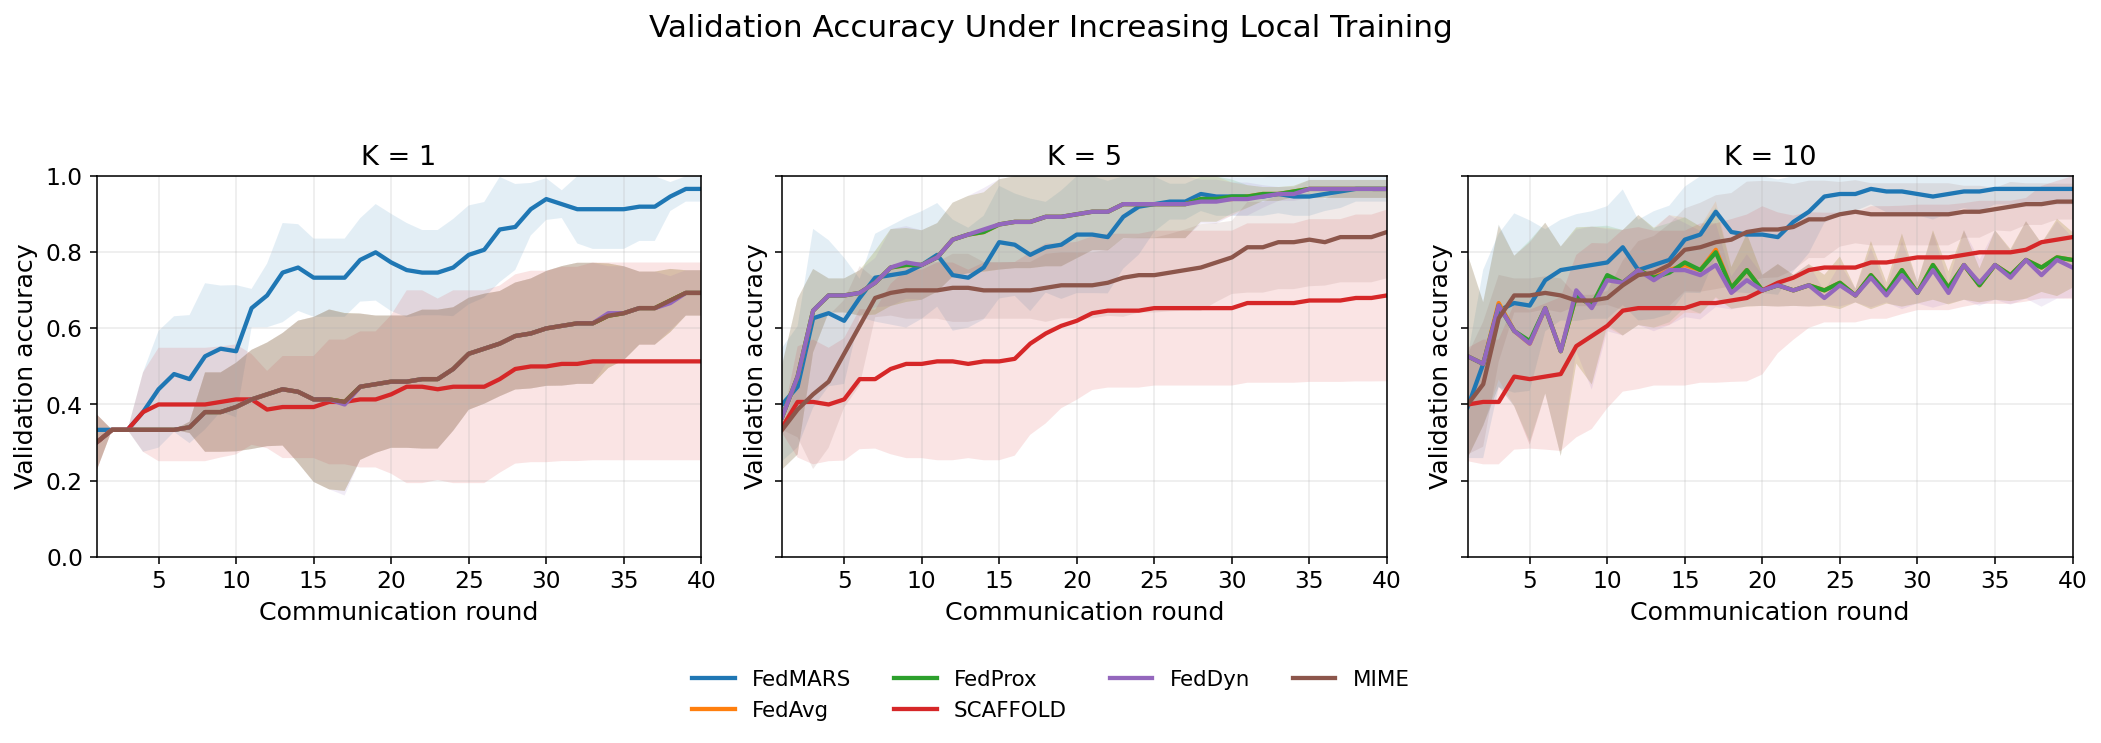

In [4]:
display(Markdown("## Validation 1 setup"))
display(pd.DataFrame([{
    "methods": "FedMARS + FedAvg + FedProx + SCAFFOLD + FedDyn + MIME",
    "seeds": len(EXPERIMENT_SEEDS),
    "heterogeneity_alphas": str(ALPHAS),
    "local_epochs_grid": str(LOCAL_EPOCH_GRID),
    "rounds": NUM_ROUNDS,
    "clients": DEFAULT_NUM_CLIENTS,
    "client_fraction": CLIENT_FRACTION,
    "batch_size": LOCAL_BATCH_SIZE,
    "local_lr": LOCAL_LR,
    "weight_decay": WEIGHT_DECAY,
    "split": "60/20/20 (train/validation/test)",
}]))

run_df, curve_df, summary_df, curve_mean_df, dataset_info = run_validation1(UCI_ID)


display(Markdown("## Final test accuracy"))
display(make_accuracy_styler(summary_df))

display(Markdown("## Final test loss"))
display(make_loss_styler(summary_df))

display(Markdown("## Rounds to target"))
display(make_rounds_styler(summary_df))


display(Markdown("## Validation loss: statistical heterogeneity"))
plot_heterogeneity_loss(
    curve_mean_df=curve_mean_df,
    fixed_local_epochs=FOCUS_LOCAL_EPOCH_FOR_HETEROGENEITY_FIG,
)

display(Markdown("## Validation loss: local training"))
plot_local_training_loss(
    curve_mean_df=curve_mean_df,
    fixed_alpha=FOCUS_ALPHA_FOR_LOCAL_TRAINING_FIG,
)

display(Markdown("## Validation accuracy: statistical heterogeneity"))
plot_heterogeneity_accuracy(
    curve_mean_df=curve_mean_df,
    fixed_local_epochs=FOCUS_LOCAL_EPOCH_FOR_HETEROGENEITY_FIG,
)

display(Markdown("## Validation accuracy: local training"))
plot_local_training_accuracy(
    curve_mean_df=curve_mean_df,
    fixed_alpha=FOCUS_ALPHA_FOR_LOCAL_TRAINING_FIG,
)